In [1]:
import pandas as pd

df = pd.read_csv("../data/processed/cota_2024_features.csv")

df.head()

,DriverEncoded,CompoundEncoded,TyreLife,FuelLoadProxy,Sector1Sec,Sector2Sec,Sector3Sec,LapTimeSec
0,17,1,2.0,54.0,26.845,39.996,33.150,99.991
1,17,1,6.0,50.0,27.069,39.822,32.888,99.779
2,17,1,7.0,49.0,26.838,39.793,33.100,99.731
3,17,1,8.0,48.0,26.809,39.973,33.300,100.082
4,17,1,9.0,47.0,26.901,39.932,33.199,100.032


In [17]:
X = df[[
    "DriverEncoded",
    "CompoundEncoded",
    "TyreLife",
    "FuelLoadProxy"
]]

y = df["LapTimeSec"]

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [21]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

In [23]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

In [25]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor()

gb.fit(X_train, y_train)

pred_gb = gb.predict(X_test)

In [27]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def evaluate(true, pred):
    mae = mean_absolute_error(true, pred)
    rmse = np.sqrt(mean_squared_error(true, pred))
    return mae, rmse

In [29]:
print("Linear Regression:", evaluate(y_test, pred_lr))
print("Random Forest:", evaluate(y_test, pred_rf))
print("Gradient Boosting:", evaluate(y_test, pred_gb))

Linear Regression: (0.7010448774447644, 0.9187934990882115)
Random Forest: (0.3791655084745808, 0.5620613661003331)
Gradient Boosting: (0.3909819524641462, 0.5587277474771465)


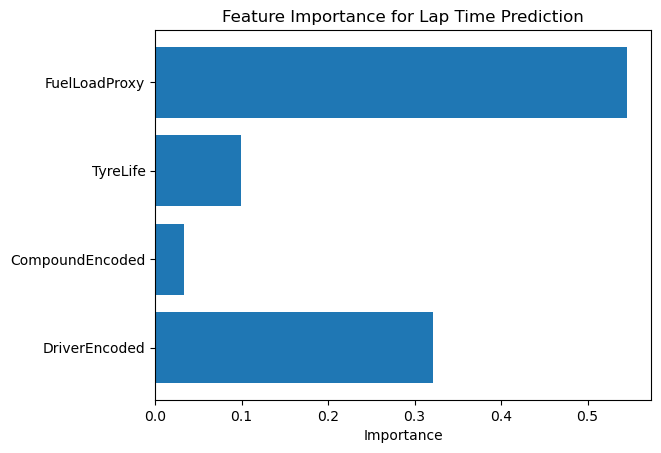

In [31]:
import matplotlib.pyplot as plt

importance = rf.feature_importances_

features = X.columns

plt.barh(features, importance)
plt.xlabel("Importance")
plt.title("Feature Importance for Lap Time Prediction")
plt.show()